# ISTAT TRAFFIC DATA ANALYSIS - ANALYSIS

In [1]:
# import packages
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# set style for plots
sns.set_style("whitegrid")

In the `data_preparation.ipynb` notebook, we cleaned, fixed, and joined the data from the ISTAT and SITUAS databases. Now, let's analyze this data to extract useful information about road accidents that occurred between 2001 and 2024. We will examine how these accidents changed over time and how they were affected by population growth in those cities.

In [2]:
# import data
# -> Use keep_default_na to avoid issues with misunderstood values as before (since now we know what to expect)

df_raw = pd.read_csv('data/istat_situas_traffic_accidents_data.csv', keep_default_na=False)

print(df_raw.info())
df_raw.head(50)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572700 entries, 0 to 572699
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   REF_AREA          572700 non-null  int64  
 1   DATA_TYPE         572700 non-null  object 
 2   RESULT            572700 non-null  object 
 3   TIME_PERIOD       572700 non-null  int64  
 4   OBS_VALUE         572700 non-null  int64  
 5   Comune            572700 non-null  object 
 6   Provincia         572700 non-null  object 
 7   Residenti         572700 non-null  float64
 8   Superficie (Kmq)  572700 non-null  float64
 9   Regione           572700 non-null  object 
 10  Degurba 2021      572700 non-null  int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 48.1+ MB
None


,REF_AREA,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE,Comune,Provincia,Residenti,Superficie (Kmq),Regione,Degurba 2021
0,1001,KILLINJ,F,2001,10,Agliè,TO,2557.0,13.1462,Piemonte,3
1,1001,KILLINJ,F,2002,10,Agliè,TO,2538.0,13.1462,Piemonte,3
2,1001,KILLINJ,F,2003,7,Agliè,TO,2588.0,13.1462,Piemonte,3
3,1001,KILLINJ,F,2004,13,Agliè,TO,2679.0,13.1462,Piemonte,3
4,1001,KILLINJ,F,2005,2,Agliè,TO,2674.0,13.1462,Piemonte,3
5,1001,KILLINJ,F,2006,1,Agliè,TO,2662.0,13.1462,Piemonte,3
6,1001,KILLINJ,F,2007,12,Agliè,TO,2658.0,13.1462,Piemonte,3
7,1001,KILLINJ,F,2008,10,Agliè,TO,2638.0,13.1462,Piemonte,3
8,1001,KILLINJ,F,2009,7,Agliè,TO,2622.0,13.1462,Piemonte,3
9,1001,KILLINJ,F,2010,14,Agliè,TO,2615.0,13.1462,Piemonte,3


## PREPARATION
Let's rename some columns to help us with the analysis

In [3]:
df_raw.rename(columns={
    'REF_AREA': 'city_id',
    'DATA_TYPE': 'accident category',
    'RESULT': 'type',
    'TIME_PERIOD': 'year',
    'OBS_VALUE': 'value',
    'Comune': 'city',
    'Provincia': 'province',
    'Regione': 'region',
    'Residenti': 'residents',
    'Superficie (Kmq)': 'area (km2)',
    'Degurba 2021': 'degurba'
    },
    inplace=True
)

df_raw.sample(5)

,city_id,accident category,type,year,value,city,province,residents,area (km2),region,degurba
75371,7019,ROADACC,9,2003,5,Charvensod,AO,2290.0,25.8619,Valle d'Aosta,2
121275,14058,KILLINJ,M,2013,0,San Giacomo Filippo,SO,390.0,61.8501,Lombardia,3
512816,91046,ROADACC,9,2012,4,Mamoiada,NU,2550.0,48.8294,Sardegna,3
255897,29045,ROADACC,9,2007,12,Stienta,RO,3249.0,24.1383,Veneto,3
92177,10045,ROADACC,9,2017,0,Propata,GE,134.0,16.9310,Liguria,3


Working with this type of data structure can be difficult. It would be much easier if we had only one row (record) for each city and year instead of three.    
To do that we can pivot the table to create three new columns for fatalities, injuries, and collisions with the respective values.  
By doing this, we can neglect the columns for `Accident Category`. Meanwhile, the values for `Type` are transformed into new columns.

In [4]:
# PIVOT TABLE

df_pivot = df_raw.pivot_table(
    index=['city_id', 'year', 'city', 'province', 'region', 'residents', 'area (km2)', 'degurba'],
    columns='type',
    values='value',
    fill_value=0,
).reset_index()

# Rename columns for clarity
df_pivot = df_pivot.rename(columns={
    '9': 'collisions',
    'F': 'injuries',
    'M': 'fatalities'
    }
)

df_pivot

type,city_id,year,city,province,region,residents,area (km2),degurba,collisions,injuries,fatalities
0,1001,2001,Agliè,TO,Piemonte,2557.0,13.1462,3,5.0,10.0,0.0
1,1001,2002,Agliè,TO,Piemonte,2538.0,13.1462,3,5.0,10.0,0.0
2,1001,2003,Agliè,TO,Piemonte,2588.0,13.1462,3,4.0,7.0,0.0
3,1001,2004,Agliè,TO,Piemonte,2679.0,13.1462,3,9.0,13.0,0.0
4,1001,2005,Agliè,TO,Piemonte,2674.0,13.1462,3,2.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
190895,111107,2020,Villaspeciosa,SU,Sardegna,2549.0,27.1937,3,2.0,3.0,0.0
190896,111107,2021,Villaspeciosa,SU,Sardegna,2536.0,27.1943,3,5.0,7.0,0.0
190897,111107,2022,Villaspeciosa,SU,Sardegna,2575.0,27.1943,3,1.0,1.0,0.0
190898,111107,2023,Villaspeciosa,SU,Sardegna,2616.0,27.1943,3,4.0,5.0,0.0


**WARNING**  
As we know, this dataset includes all of Italy’s cities and independent municipalities; this also includes towns with very small populations, which create significant outliers when we calculate the number of accidents per capita. For example, in a town with 5000 residents where there are about ten accidents per year, a single fatal accident would disproportionately increase the proportion of fatal accidents out of the total, resulting in a value that is significantly above the average.  
Therefore, we’ll have to take this factor into consideration.

In [5]:
print(df_pivot.loc[df_pivot['degurba'] == 3, ['residents','area (km2)']].describe())
print()
print(df_pivot.loc[df_pivot['degurba'] == -1, ['residents','area (km2)']].describe())

type       residents     area (km2)
count  119629.000000  119629.000000
mean     2122.267694      36.406588
std      2157.326084      37.735867
min        28.000000       1.168100
25%       728.000000      13.183300
50%      1469.000000      24.061900
75%      2843.000000      44.924300
max     32080.000000     372.505100

type      residents   area (km2)
count   5809.000000  5809.000000
mean    2230.889826    22.783766
std     3642.999991    23.556358
min       34.000000     0.149500
25%      597.000000     8.028400
50%     1300.000000    15.709000
75%     2597.000000    28.915500
max    39782.000000   195.640000


We can now proceed by calculating some useful metrics for our analysis:
1) **Harmful Accidents:** total number of deaths and injuries
2) **Severity Index:** ratio of fatalities (M) and injuries (F) divided by the total collisions. This metric helps us to calculate how much dangerous the roads are
3) **Fatality Rate:** ratio of fatalities divided by the total collisions
4) **Per-Capita Accident Rate (per 10,000 residents):** ratio of accidents per 10,000 residents. This helps us avoid biased values for cities with large populations and it also indicates the number of accidents for every 10,000 inhabitants.
5) **Collision Density:** ratio of total accidents divided by the area (km2). This is useful for understanding whether the total number of accidents has increased or decreased, since the area has remained almost the same throughout the years.
6) **residents Density** ratio of residents divided by the area (km2)

In [6]:
# check min values for division
print(df_pivot['area (km2)'].min(), df_pivot['residents'].max())
print(df_pivot['year'].min(), df_pivot['year'].max())

0.1206 2820219.0
2001 2024


In [7]:
# 1) Harmful Accidents (M + F)
df_pivot['harmful_accidents'] = df_pivot['fatalities'] + df_pivot['injuries']

# 2) Severity Index (where condition to taking into account possible division by zero)
df_pivot['severity_index'] = np.where(df_pivot['collisions'] > 0, df_pivot['harmful_accidents'] / df_pivot['collisions'], 0)

# 3) Fatality Rate
df_pivot['fatality_rate'] = np.where(df_pivot['collisions'] > 0, df_pivot['fatalities'] / df_pivot['collisions'], 0)

# 4) Per-Capita Accidents Rate
df_pivot['per_capita_accidents_rate'] = (df_pivot['collisions'] / df_pivot['residents']) * 1e4

# 5) Collision Density
df_pivot['collision_density'] = df_pivot['collisions'] / df_pivot['area (km2)']

# 6) Resident Density
df_pivot['resident_density'] = df_pivot['residents'] / df_pivot['area (km2)']

df_pivot


type,city_id,year,city,province,region,residents,area (km2),degurba,collisions,injuries,fatalities,harmful_accidents,severity_index,fatality_rate,per_capita_accidents_rate,collision_density,resident_density
0,1001,2001,Agliè,TO,Piemonte,2557.0,13.1462,3,5.0,10.0,0.0,10.0,2.000000,0.0,19.554165,0.380338,194.504876
1,1001,2002,Agliè,TO,Piemonte,2538.0,13.1462,3,5.0,10.0,0.0,10.0,2.000000,0.0,19.700552,0.380338,193.059591
2,1001,2003,Agliè,TO,Piemonte,2588.0,13.1462,3,4.0,7.0,0.0,7.0,1.750000,0.0,15.455951,0.304270,196.862972
3,1001,2004,Agliè,TO,Piemonte,2679.0,13.1462,3,9.0,13.0,0.0,13.0,1.444444,0.0,33.594625,0.684608,203.785124
4,1001,2005,Agliè,TO,Piemonte,2674.0,13.1462,3,2.0,2.0,0.0,2.0,1.000000,0.0,7.479432,0.152135,203.404786
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190895,111107,2020,Villaspeciosa,SU,Sardegna,2549.0,27.1937,3,2.0,3.0,0.0,3.0,1.500000,0.0,7.846214,0.073546,93.734946
190896,111107,2021,Villaspeciosa,SU,Sardegna,2536.0,27.1943,3,5.0,7.0,0.0,7.0,1.400000,0.0,19.716088,0.183862,93.254836
190897,111107,2022,Villaspeciosa,SU,Sardegna,2575.0,27.1943,3,1.0,1.0,0.0,1.0,1.000000,0.0,3.883495,0.036772,94.688961
190898,111107,2023,Villaspeciosa,SU,Sardegna,2616.0,27.1943,3,4.0,5.0,0.0,5.0,1.250000,0.0,15.290520,0.147090,96.196629


Let's also create another data frame that takes the entire time span and sums all the accident values. For the area and residents we will take the mean values across the years since municipal boundaries rarely change in Italy.  

In [8]:
df_pivot_24y = df_pivot.groupby(['city_id']).agg(
                                            city=('city', 'last'),
                                            province=('province', 'last'),
                                            region=('region', 'last'),
                                            mean_residents_years=('residents', 'mean'),
                                            mean_area_km2=('area (km2)', 'mean'),
                                            total_collisions=('collisions', 'sum'),
                                            total_fatalities=('fatalities', 'sum'),
                                            total_injuries=('injuries', 'sum'),
                                            years_recorded=('year', 'count'),
                                        ).reset_index()


# calculcate again the metrics
# 2) Harmful Accidents (M + F)
df_pivot_24y['harmful_accidents'] = df_pivot_24y['total_fatalities'] + df_pivot_24y['total_injuries']

# 3) Severity Index (where condition to taking into account possible division by zero)
df_pivot_24y['severity_index'] = np.where(df_pivot_24y['total_collisions'] > 0, df_pivot_24y['harmful_accidents'] / df_pivot_24y['total_collisions'], 0,)

# 4) Fatality Rate
df_pivot_24y['fatality_rate'] = np.where(df_pivot_24y['total_collisions'] > 0, df_pivot_24y['total_fatalities'] / df_pivot_24y['total_collisions'], 0,)

# 5) Per-Capita Accidents Rate
df_pivot_24y['per_capita_accidents_rate'] = (df_pivot_24y['total_collisions'] / df_pivot_24y['mean_residents_years']) * 1e4

# 6) Collision Density
df_pivot_24y['collision_density'] = df_pivot_24y['total_collisions'] / df_pivot_24y['mean_area_km2']

# 7) Resident Density
df_pivot_24y['resident_density'] = df_pivot_24y['mean_residents_years'] / df_pivot_24y['mean_area_km2']

df_pivot_24y

,city_id,city,province,region,mean_residents_years,mean_area_km2,total_collisions,total_fatalities,total_injuries,years_recorded,harmful_accidents,severity_index,fatality_rate,per_capita_accidents_rate,collision_density,resident_density
0,1001,Agliè,TO,Piemonte,2630.541667,13.146217,95.0,1.0,161.0,24,162.0,1.705263,0.010526,361.142350,7.226414,200.098761
1,1002,Airasca,TO,Piemonte,3699.041667,15.739300,262.0,8.0,427.0,24,435.0,1.660305,0.030534,708.291562,16.646230,235.019452
2,1003,Ala di Stura,TO,Piemonte,463.875000,46.331517,6.0,0.0,10.0,24,10.0,1.666667,0.000000,129.345190,0.129501,10.012083
3,1004,Albiano d'Ivrea,TO,Piemonte,1696.000000,11.732788,107.0,10.0,165.0,24,175.0,1.635514,0.093458,630.896226,9.119742,144.552179
4,1005,Alice Superiore,TO,Piemonte,687.222222,7.379600,21.0,5.0,34.0,18,39.0,1.857143,0.238095,305.578011,2.845683,93.124590
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8573,111103,Villaputzu,SU,Sardegna,4529.625000,181.351050,48.0,5.0,70.0,8,75.0,1.562500,0.104167,105.969037,0.264680,24.977109
8574,111104,Villasalto,SU,Sardegna,981.000000,130.359600,18.0,1.0,26.0,8,27.0,1.500000,0.055556,183.486239,0.138080,7.525338
8575,111105,Villasimius,SU,Sardegna,3707.500000,58.074450,54.0,5.0,74.0,8,79.0,1.462963,0.092593,145.650708,0.929841,63.840467
8576,111106,Villasor,SU,Sardegna,6692.125000,86.803600,104.0,11.0,157.0,8,168.0,1.615385,0.105769,155.406541,1.198107,77.095017


First, let's look at top-of-mind questions, such as which city has the most and fewest accidents. Since we can see from the above data frame that there are cities without any accidents, we will take the cities that have had zero total accidents.  
We also print the city with the highest per capita values of accidents to compare it with the city that has the highest number of accidents.

In [9]:
print(f'City with the highest total number of accidents in 24 years: {df_pivot_24y.loc[df_pivot_24y["total_collisions"].idxmax(), "city"]}')
print(f'Cities with the lowest total number of accidents in 24 years: {df_pivot_24y.loc[df_pivot_24y["total_collisions"] == 0, "city"].values.shape[0]}')
print(f'City with the highest Per-Capita Accidents Rate in 24 years: {df_pivot_24y.loc[df_pivot_24y["per_capita_accidents_rate"].idxmax(), "city"]}')

City with the highest total number of accidents in 24 years: Roma
Cities with the lowest total number of accidents in 24 years: 67
City with the highest Per-Capita Accidents Rate in 24 years: Belforte Monferrato


As expected, in the time span of 24 years, Rome has the highest number of accidents because it is the capital and has the largest population in Italy. However, when we look at the number of accidents per capita, Jesolo has the highest number. Jesolo is a beach destination that attracts many tourists, and it is also famous for its nightlife. These factors could explain the high per capita accident rate.

In [10]:
# print the top 10 cities by accidents per-capita

df_pivot_24y.sort_values(by='per_capita_accidents_rate', ascending=False).reset_index(drop=True).iloc[:10]

,city_id,city,province,region,mean_residents_years,mean_area_km2,total_collisions,total_fatalities,total_injuries,years_recorded,harmful_accidents,severity_index,fatality_rate,per_capita_accidents_rate,collision_density,resident_density
0,6014,Belforte Monferrato,AL,Piemonte,486.833333,8.325800,271.0,9.0,435.0,24,444.0,1.638376,0.033210,5566.586785,32.549425,58.472859
1,4175,Priero,CN,Piemonte,511.000000,19.976367,210.0,5.0,327.0,24,332.0,1.580952,0.023810,4109.589041,10.512422,25.580227
2,21065,Ponte Gardena/Waidbruck,BZ,Trentino-Alto Adige/Südtirol,199.625000,2.317742,77.0,0.0,110.0,24,110.0,1.428571,0.000000,3857.232311,33.221994,86.129098
3,46013,Forte dei Marmi,LU,Toscana,7567.291667,8.957700,2887.0,22.0,3857.0,24,3879.0,1.343609,0.007620,3815.103378,322.292553,844.780654
4,12024,Brusimpiano,VA,Lombardia,1162.375000,5.905800,425.0,6.0,538.0,24,544.0,1.280000,0.014118,3656.307130,71.963155,196.819229
5,97032,Dorio,LC,Lombardia,335.000000,11.655600,116.0,7.0,177.0,23,184.0,1.586207,0.060345,3462.686567,9.952298,28.741549
6,34004,Berceto,PR,Emilia-Romagna,2160.958333,131.704583,726.0,33.0,1012.0,24,1045.0,1.439394,0.045455,3359.620539,5.512337,16.407617
7,7009,Bard,AO,Valle d'Aosta,125.333333,3.031458,42.0,6.0,67.0,24,73.0,1.738095,0.142857,3351.063830,13.854718,41.344238
8,4006,Argentera,CN,Piemonte,86.291667,76.259117,28.0,1.0,37.0,24,38.0,1.357143,0.035714,3244.809271,0.367169,1.131559
9,58069,Nazzano,RM,Lazio,1356.208333,12.396933,435.0,12.0,776.0,24,788.0,1.811494,0.027586,3207.471812,35.089323,109.398695


In [11]:
df_pivot_24y.loc[df_pivot_24y['city'].isin(['Roma', 'Belforte Monferrato'])]

,city_id,city,province,region,mean_residents_years,mean_area_km2,total_collisions,total_fatalities,total_injuries,years_recorded,harmful_accidents,severity_index,fatality_rate,per_capita_accidents_rate,collision_density,resident_density
877,6014,Belforte Monferrato,AL,Piemonte,4.868333e+02,8.325800,271.0,9.0,435.0,24,444.0,1.638376,0.033210,5566.586785,32.549425,58.472859
5114,58091,Roma,RM,Lazio,2.693100e+06,1287.499925,390605.0,4350.0,506345.0,24,510695.0,1.307446,0.011137,1450.391921,303.382542,2091.728018


Even though Jesolo is much smaller than Rome, it has a higher severity index and fatality rate than Rome, and almost 1.5 times the number of accidents per capita.  
Let's have a look at some plots.

## VISUALIZING INFORMATION
First, we can examine how the following metrics change over time for Rome (a large city) and Belforte Monferrato (a small town with a high accident rate): accidents per capita, severity index, fatality rate, and collision density.    
We will use a line plot, where the x-axis represents the years and the y-axis represents the values of the metric.

In [12]:
def realplot_year_comparison(df, hue, xaxis, metrics, metric_labels):

    # melt dataframe
    df_melted = df.melt(
        id_vars=[hue, xaxis],
        value_vars=metrics,
        var_name='metric',
        value_name='value',
    )
    df_melted['metric'] = df_melted['metric'].map(metric_labels)

    g = sns.relplot(
        data=df_melted,
        x=xaxis,
        y='value',
        hue=hue,
        col='metric',
        col_wrap=2,
        kind='line',
        height=4,
        aspect=1.5,
        facet_kws={'sharey': False},
        linewidth=1.5,
        marker='o',
        errorbar=None,
    )

    g.set_titles(col_template='{col_name}', weight='bold')
    g.set_axis_labels(xaxis, 'Value')
    g.fig.subplots_adjust(top=0.9)
    g.fig.suptitle(f'2001-2024 Road Accidents Trends', fontsize=16, weight='bold')
    plt.show()

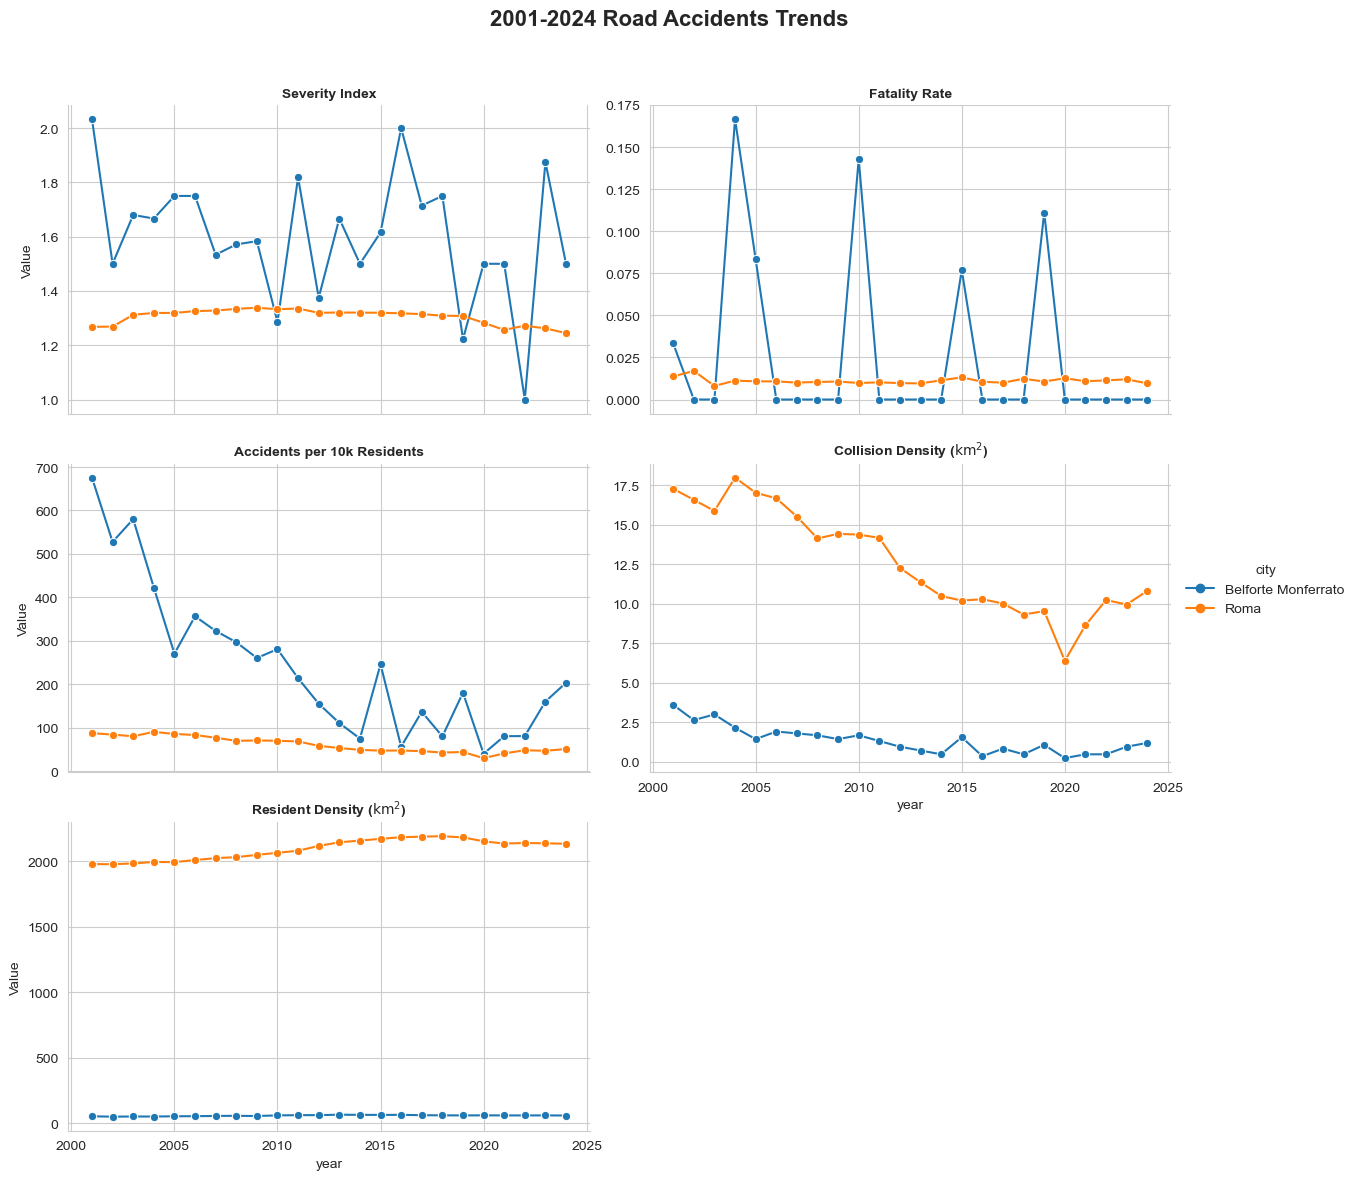

In [13]:
locations = ['Roma', 'Belforte Monferrato']

metrics = ['severity_index', 'fatality_rate', 'per_capita_accidents_rate', 'collision_density', 'resident_density']
metric_labels = {
    'per_capita_accidents_rate': 'Accidents per 10k Residents',
    'severity_index': 'Severity Index',
    'fatality_rate': 'Fatality Rate',
    'collision_density': r'Collision Density ($\text{km}^2$)',
    'resident_density': r'Resident Density ($\text{km}^2$)',
}
realplot_year_comparison(df_pivot[df_pivot['city'].isin(locations)], 'city', 'year', metrics, metric_labels)

The first thing we can see from this plot is that, upon closer observation of per capita and collision density, the number of accidents in both cities decreased. There was also a slight decrease in the Severity Index meanwhile Fatality Rate remain unchanged. This could be a sign that the number of accidents has changed over time due to car safety regulations, road quality, and other general regulations, but the risk of death don't. Only Rome presents an increase in population, which could indicate that the number of accidents near 2024 increased due to the increase in population. However, the risk of injury has decreased.
Of course, these are just initial hypotheses based on a small sample, so it’s impossible to provide a precise estimate of the trend. For example, let’s compare the major Italian cities to see if these trends are similar across them.
It is also important to note that the spikes in the severity index and the fatality rate in Belforte Monferrato are due to what we mentioned before: small cities with small populations have few fatal accidents, but when they occur, the rate increases drastically.

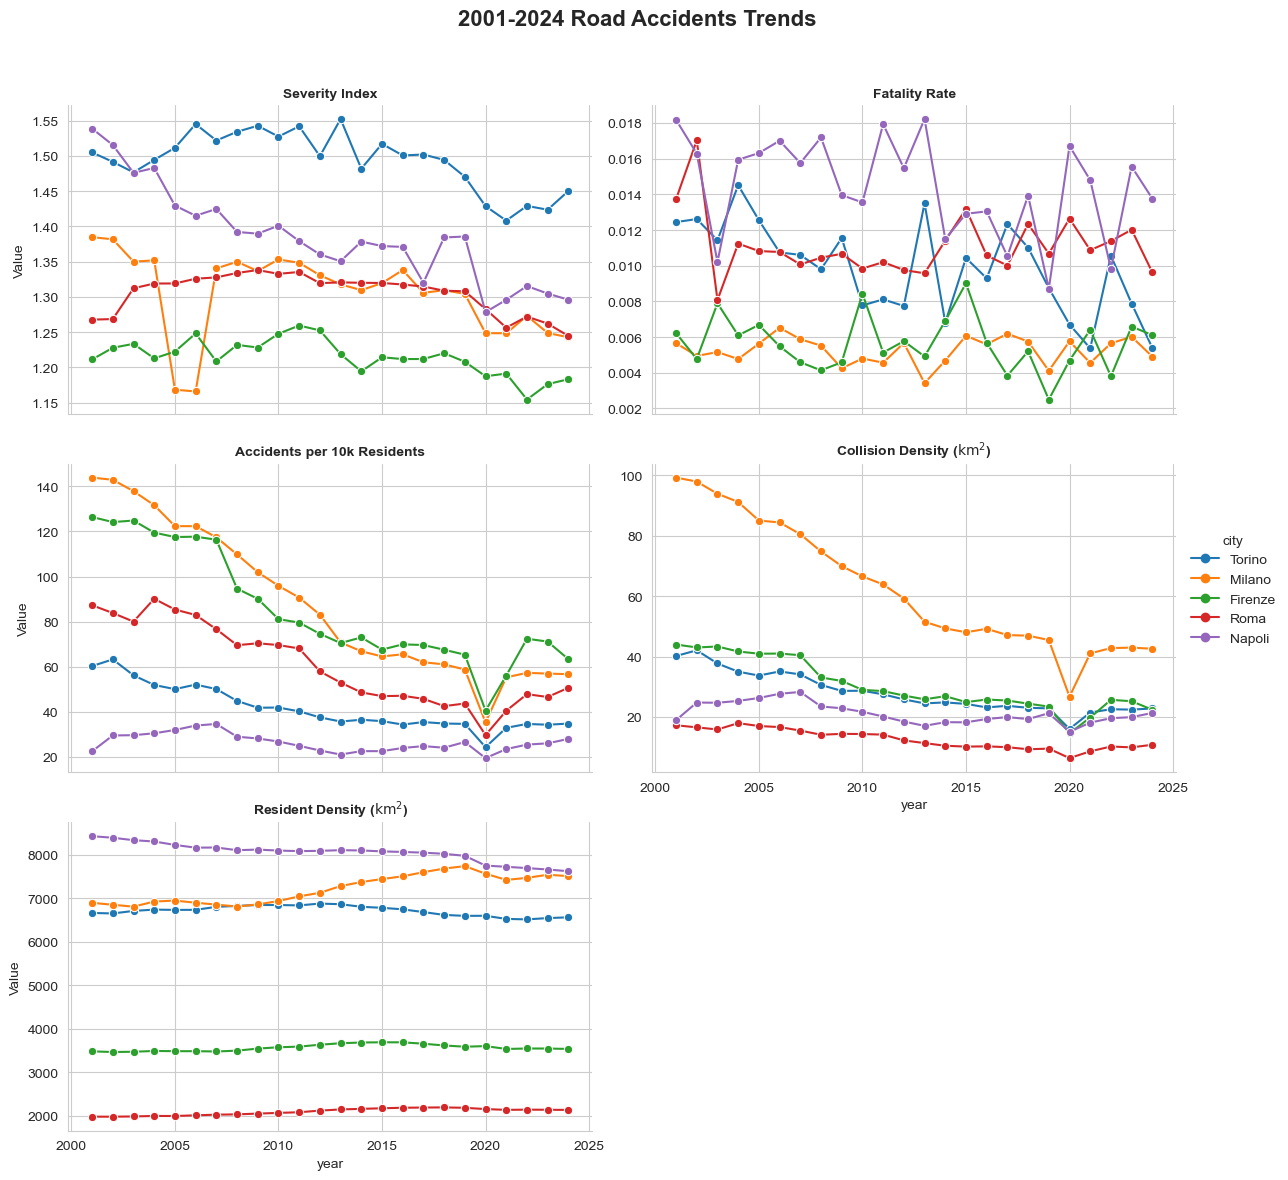

In [14]:
locations = ['Roma', 'Milano', 'Torino', 'Napoli', 'Firenze']

realplot_year_comparison(df_pivot[df_pivot['city'].isin(locations)], 'city', 'year', metrics, metric_labels)

We can see some information from this graph:
- we can see that the trend described earlier, how the number of accidents has decreased over the years, also holds true for other major cities besides Rome.
- the number of accidents dropped dramatically in 2020; this is due to the COVID-19 pandemic and the lockdown, during which residents were largely unable to travel freely by car for much of that year. Therefore, 2020 should not be fully factored into our analysis, as it represents a very specific case and thus introduces a bias in our calculations.
- Among Italy’s most populous cities, Milan has the highest number of accidents (see per-capita and collision density), but it is also among those cities, along with Florence, where the vast majority of accidents are simple collisions.
In fact, cities like Turin, but especially Naples, have the lowest number of accidents yet the highest severity index and fatality rate, with Naples leading the latter.  
One possible explanation for these figures is that Milan, with its heavy traffic, experiences accidents that occur at low speeds, whereas in Naples, the high fatality rate may be caused by the widespread use of mopeds, which are far more dangerous than cars.
- The most densely populated cities have the highest severity index, meaning fewer accidents but more injuries. Meanwhile, there is no clear distinction in the number of deaths. 

We can see that the downward trend in the number of accidents in Italy is consistent across regions as well, since, precisely because of the country’s geography, the terrain on which the roads are built can influence the number of accidents in Italy (Take Belforte Monferrato as an examplewhich is built on top of a hill).

In [15]:
# group by region
df_pivot_region = df_pivot.groupby(['region', 'year']).agg(
                                                        sum_residents=('residents', 'sum'),
                                                        region_area=('area (km2)', 'sum'),
                                                        collisions=('collisions', 'sum'),
                                                        injuries=('injuries', 'sum'),
                                                        fatalities=('fatalities', 'sum'),
                                                    ).reset_index()

# calculcate again the metrics
# 2. Harmful Accidents (M + F)
df_pivot_region['harmful_accidents'] = df_pivot_region['fatalities'] + df_pivot_region['injuries']

# 3. Severity Index (where condition to taking into account possible division by zero)
df_pivot_region['severity_index'] = np.where(df_pivot_region['collisions'] > 0, df_pivot_region['harmful_accidents'] / df_pivot_region['collisions'], 0,)

# 4. Fatality Rate
df_pivot_region['fatality_rate'] = np.where(df_pivot_region['collisions'] > 0, df_pivot_region['fatalities'] / df_pivot_region['collisions'], 0,)

# 5. Per-Capita Accidents Rate
df_pivot_region['per_capita_accidents_rate'] = (df_pivot_region['collisions'] / df_pivot_region['sum_residents']) * 1e4

# 6. Collision Density
df_pivot_region['collision_density'] = df_pivot_region['collisions'] / df_pivot_region['region_area']

# 7) Resident Density
df_pivot_region['resident_density'] = df_pivot_region['sum_residents'] / df_pivot_region['region_area']

df_pivot_region

,region,year,sum_residents,region_area,collisions,injuries,fatalities,harmful_accidents,severity_index,fatality_rate,per_capita_accidents_rate,collision_density,resident_density
0,Abruzzo,2001,1262187.0,10831.5397,5574.0,8342.0,168.0,8510.0,1.526731,0.030140,44.161444,0.514608,116.528862
1,Abruzzo,2002,1267633.0,10831.5370,5495.0,8496.0,185.0,8681.0,1.579800,0.033667,43.348509,0.507315,117.031683
2,Abruzzo,2003,1278658.0,10831.5370,5286.0,8066.0,154.0,8220.0,1.555051,0.029134,41.340218,0.488019,118.049544
3,Abruzzo,2004,1287157.0,10831.5370,4977.0,7544.0,141.0,7685.0,1.544103,0.028330,38.666612,0.459492,118.834197
4,Abruzzo,2005,1292999.0,10831.5370,4814.0,7225.0,134.0,7359.0,1.528666,0.027835,37.231274,0.444443,119.373548
...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,Veneto,2020,4869830.0,18345.3694,9839.0,12919.0,229.0,13148.0,1.336315,0.023275,20.203991,0.536321,265.452818
476,Veneto,2021,4847745.0,18355.2293,12403.0,16512.0,285.0,16797.0,1.354269,0.022978,25.585092,0.675720,264.107025
477,Veneto,2022,4849553.0,18355.2293,13220.0,17286.0,321.0,17607.0,1.331846,0.024281,27.260244,0.720231,264.205525
478,Veneto,2023,4852216.0,18355.2293,12774.0,16994.0,309.0,17303.0,1.354548,0.024190,26.326116,0.695932,264.350607


To make our lives easier, we create a relplot for the grouped regions of North, Center, and South, which makes the plot much easier to read.

In [16]:
df_pivot_region['region'].unique()

array(['Abruzzo', 'Basilicata', 'Calabria', 'Campania', 'Emilia-Romagna',
       'Friuli-Venezia Giulia', 'Lazio', 'Liguria', 'Lombardia', 'Marche',
       'Molise', 'Piemonte', 'Puglia', 'Sardegna', 'Sicilia', 'Toscana',
       'Trentino-Alto Adige/Südtirol', 'Umbria', "Valle d'Aosta",
       'Veneto'], dtype=object)

In [17]:
italian_regions_istat = {
    # Nord-Ovest
    "Piemonte": "North-West",
    "Valle d'Aosta": "North-West",
    "Lombardia": "North-West",
    "Liguria": "North-West",
    # Nord-Est
    "Trentino-Alto Adige": "North-East",
    "Veneto": "North-East",
    "Friuli-Venezia Giulia": "North-East",
    "Emilia-Romagna": "North-East",
    # Centro
    "Toscana": "Center",
    "Umbria": "Center",
    "Marche": "Center",
    "Lazio": "Center",
    # Sud e Isole
    "Abruzzo": "South",
    "Molise": "South",
    "Campania": "South",
    "Puglia": "South",
    "Basilicata": "South",
    "Calabria": "South",
    "Sicilia": "Islands",
    "Sardegna": "Islands",
}

df_pivot_region['location'] = np.empty(df_pivot_region.shape[0], dtype=object)
df_pivot_region['location'] = df_pivot_region['region'].map(italian_regions_istat)
df_pivot_region

,region,year,sum_residents,region_area,collisions,injuries,fatalities,harmful_accidents,severity_index,fatality_rate,per_capita_accidents_rate,collision_density,resident_density,location
0,Abruzzo,2001,1262187.0,10831.5397,5574.0,8342.0,168.0,8510.0,1.526731,0.030140,44.161444,0.514608,116.528862,South
1,Abruzzo,2002,1267633.0,10831.5370,5495.0,8496.0,185.0,8681.0,1.579800,0.033667,43.348509,0.507315,117.031683,South
2,Abruzzo,2003,1278658.0,10831.5370,5286.0,8066.0,154.0,8220.0,1.555051,0.029134,41.340218,0.488019,118.049544,South
3,Abruzzo,2004,1287157.0,10831.5370,4977.0,7544.0,141.0,7685.0,1.544103,0.028330,38.666612,0.459492,118.834197,South
4,Abruzzo,2005,1292999.0,10831.5370,4814.0,7225.0,134.0,7359.0,1.528666,0.027835,37.231274,0.444443,119.373548,South
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,Veneto,2020,4869830.0,18345.3694,9839.0,12919.0,229.0,13148.0,1.336315,0.023275,20.203991,0.536321,265.452818,North-East
476,Veneto,2021,4847745.0,18355.2293,12403.0,16512.0,285.0,16797.0,1.354269,0.022978,25.585092,0.675720,264.107025,North-East
477,Veneto,2022,4849553.0,18355.2293,13220.0,17286.0,321.0,17607.0,1.331846,0.024281,27.260244,0.720231,264.205525,North-East
478,Veneto,2023,4852216.0,18355.2293,12774.0,16994.0,309.0,17303.0,1.354548,0.024190,26.326116,0.695932,264.350607,North-East


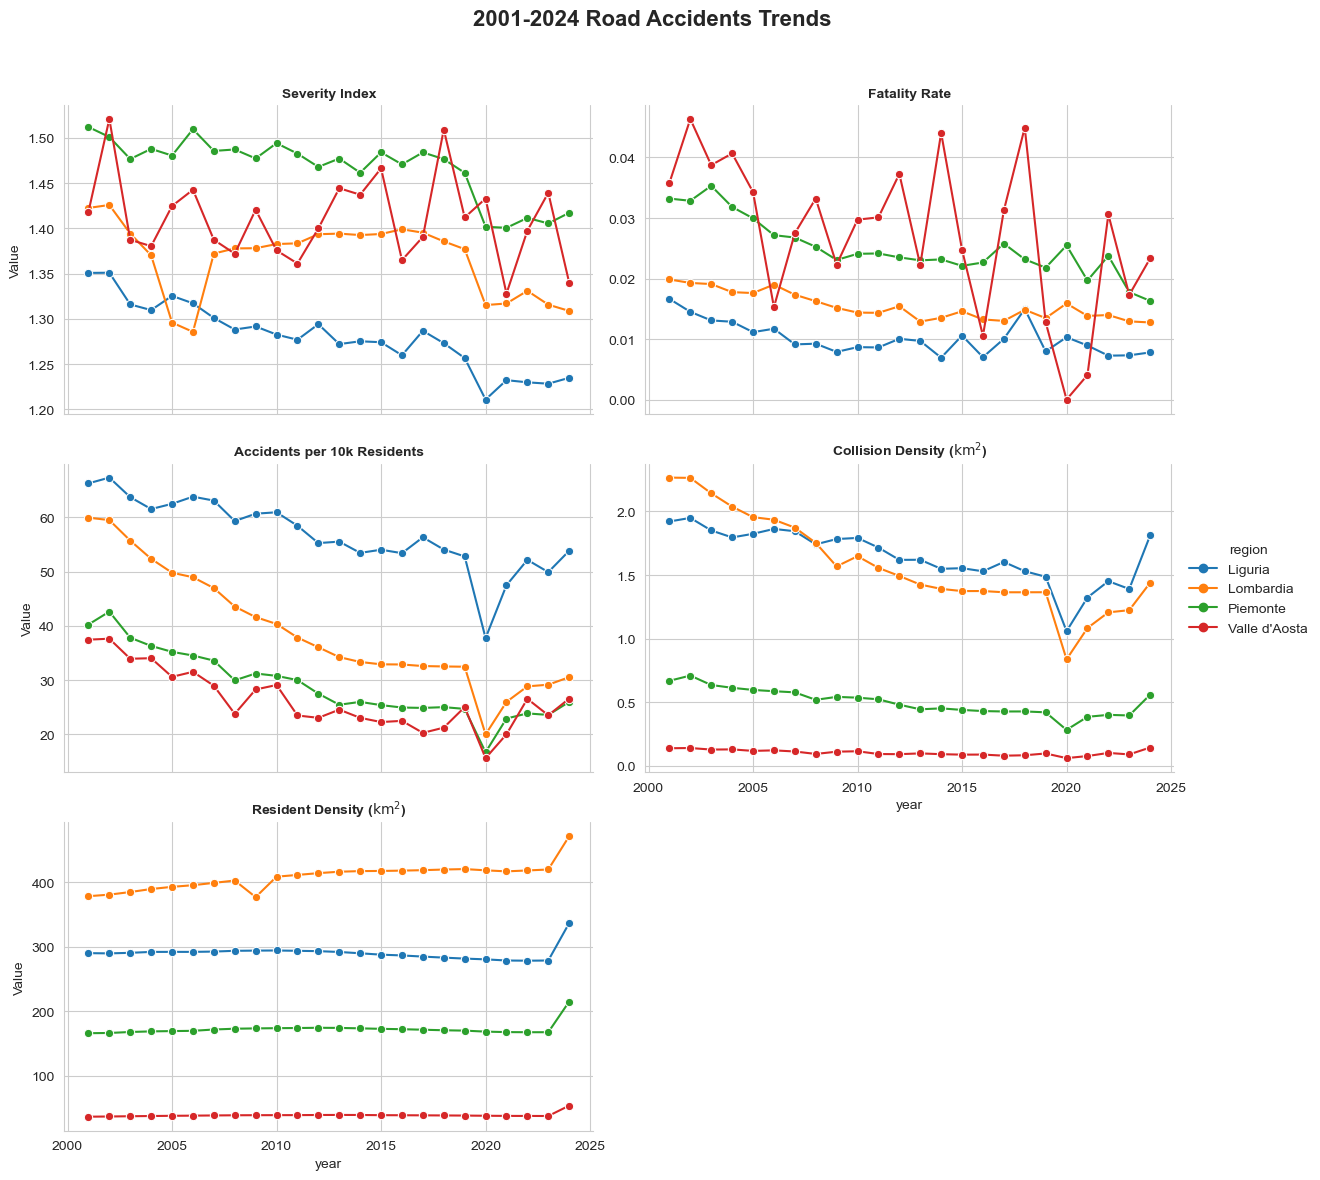

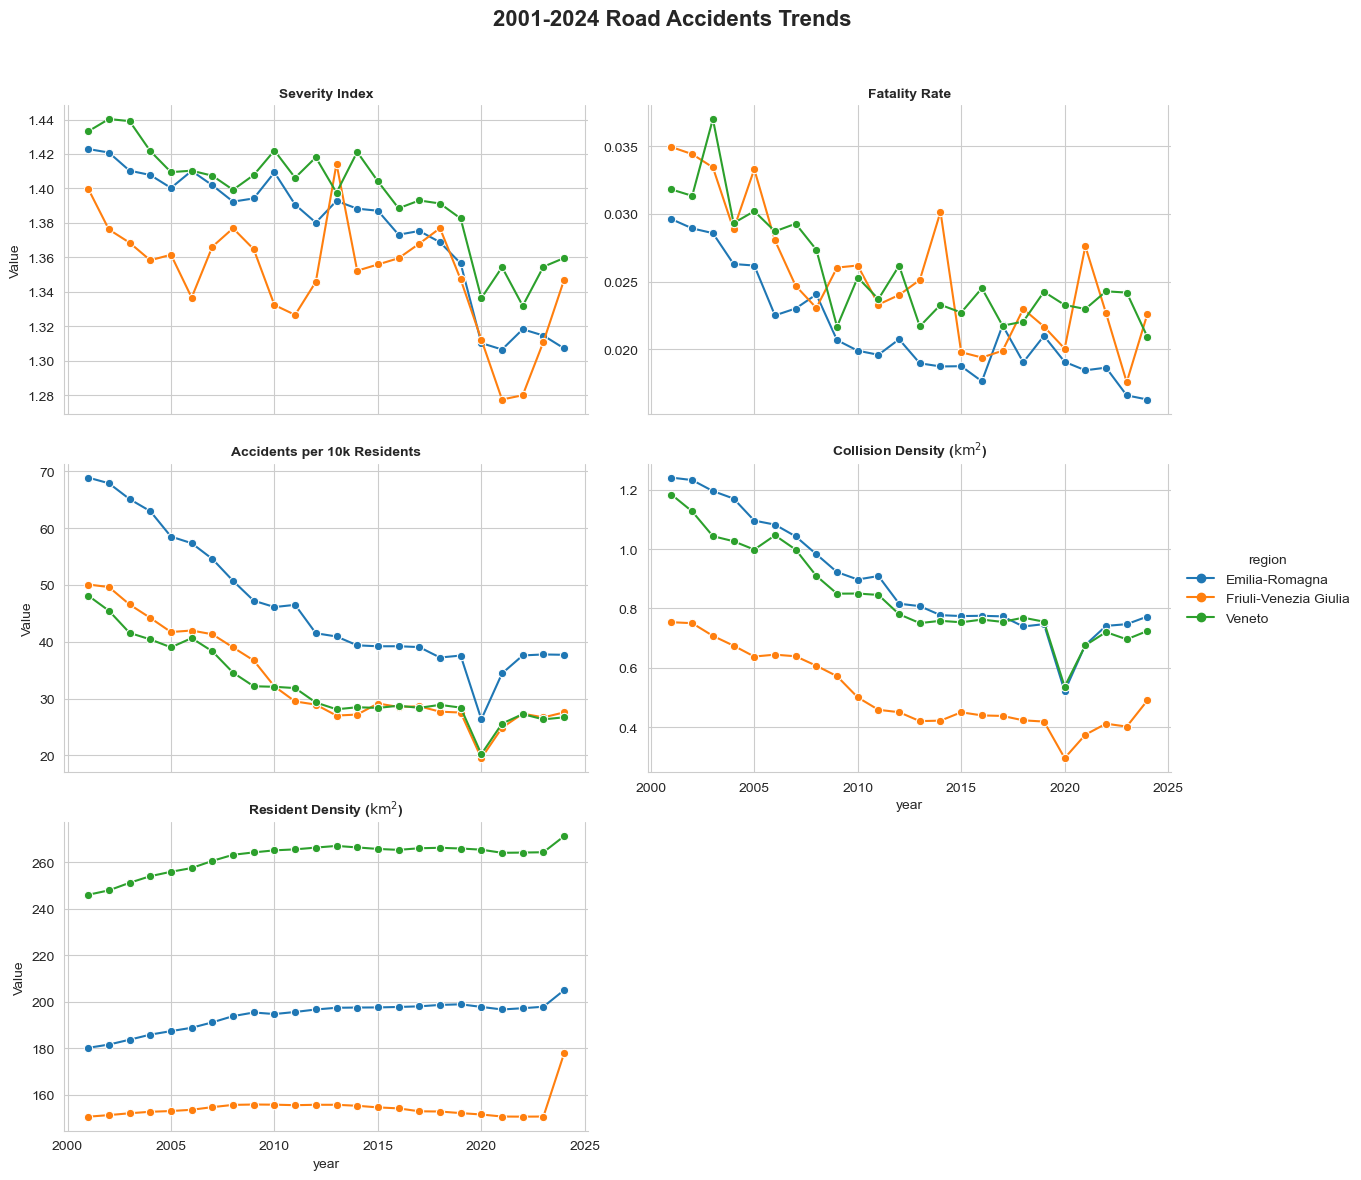

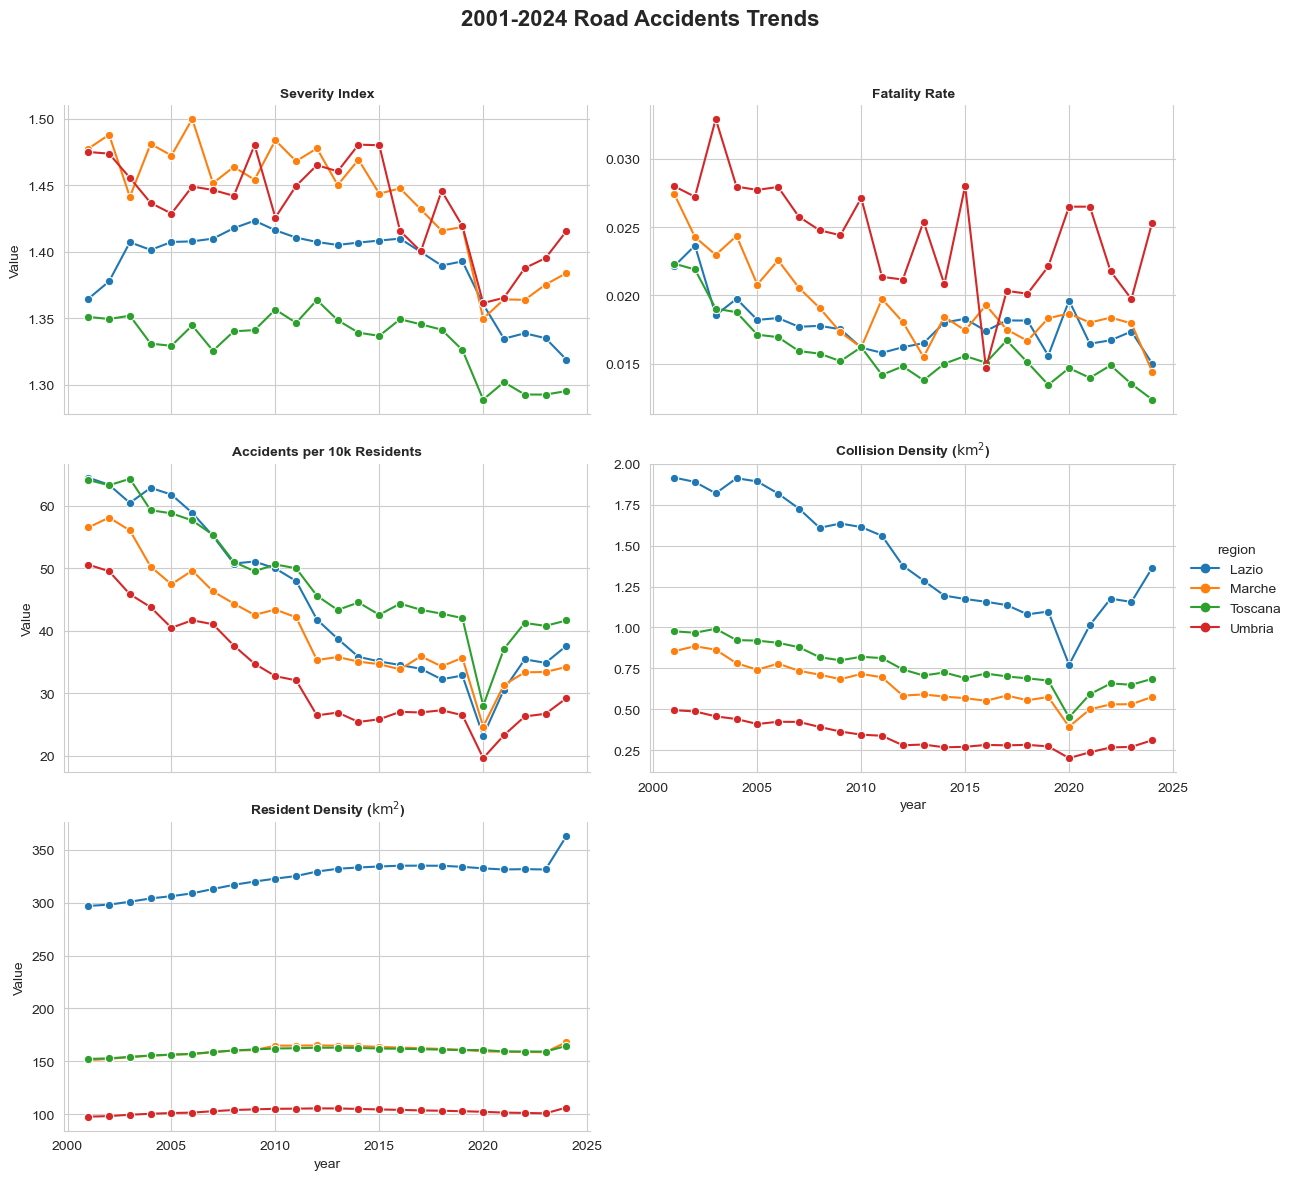

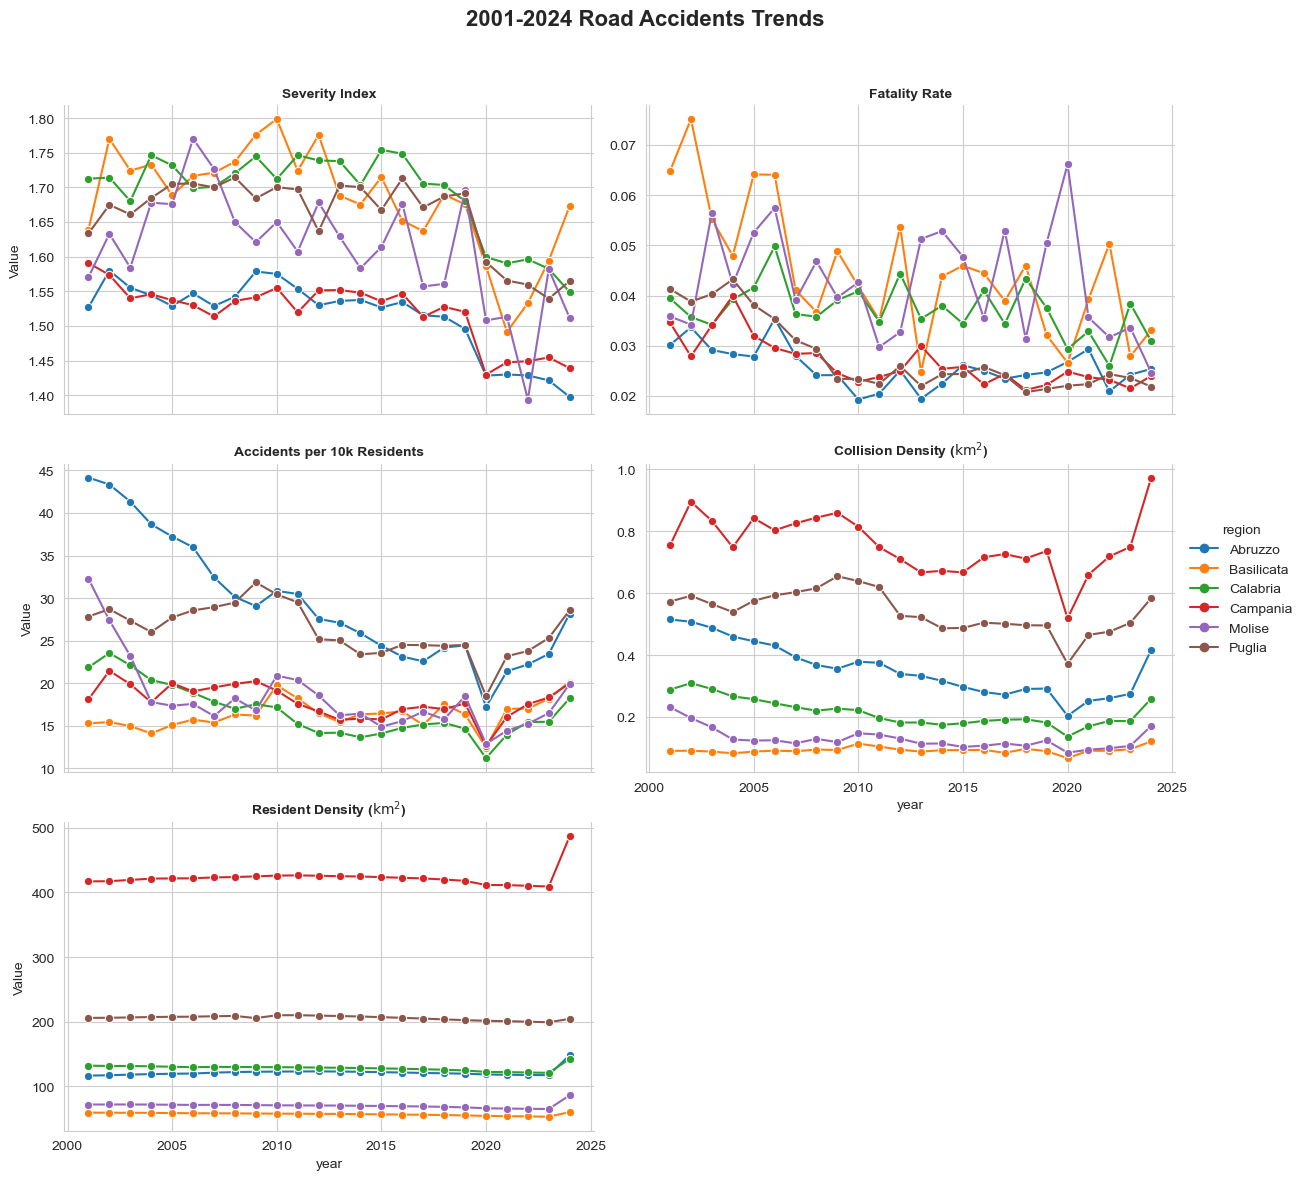

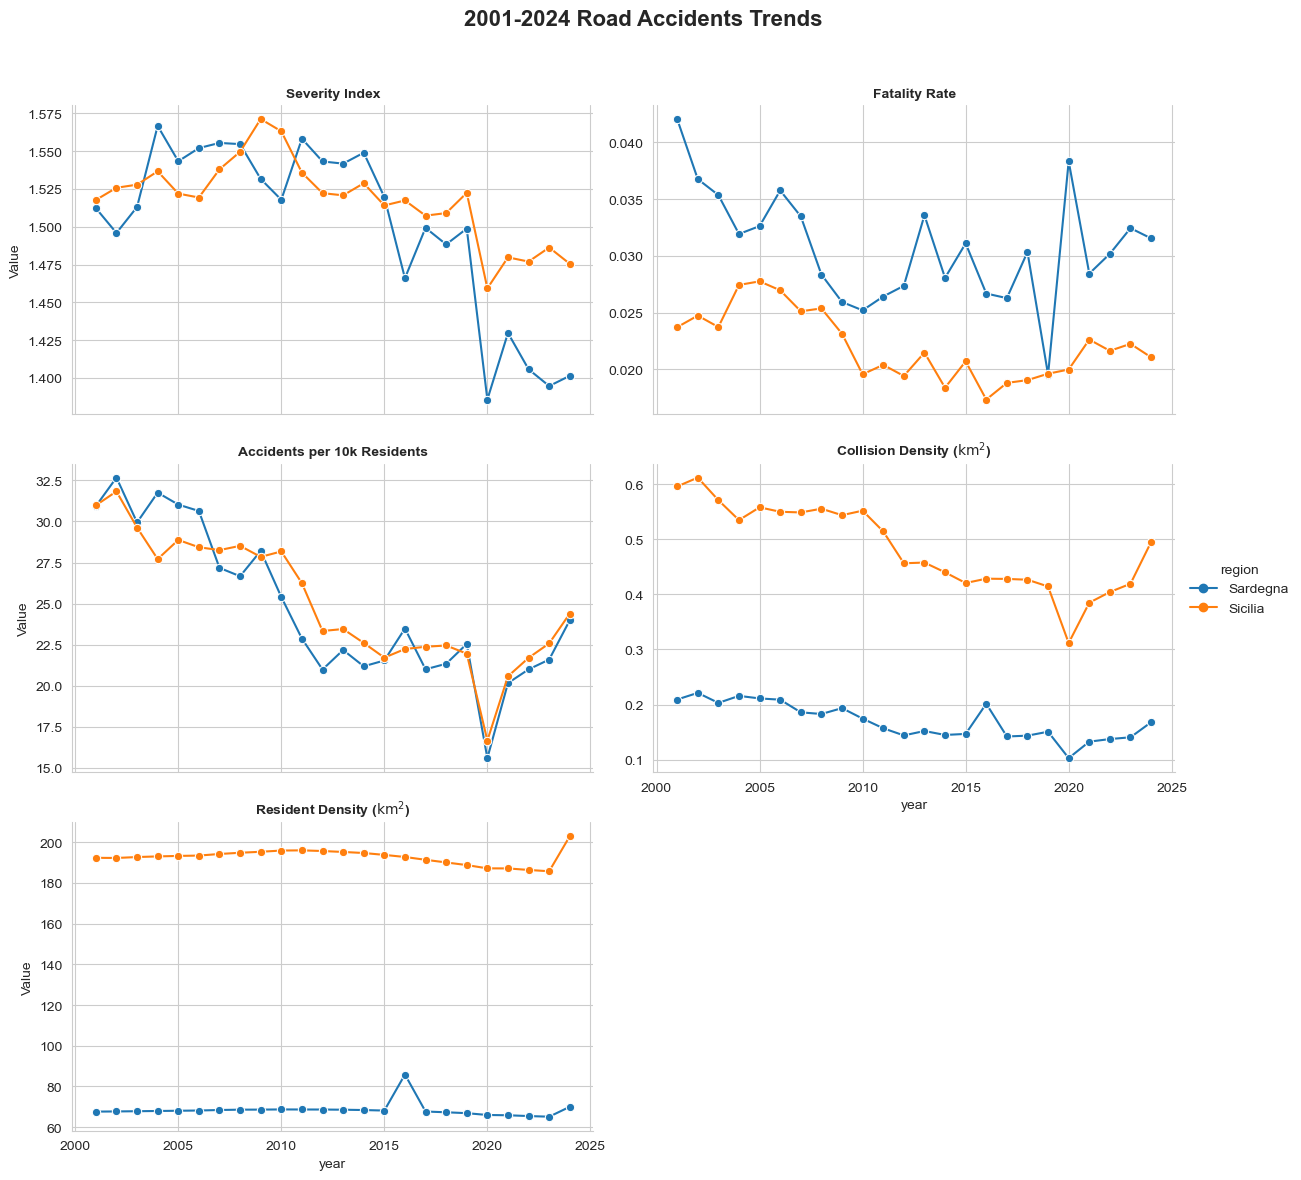

In [18]:
# North-West (Nord-Ovest)
north_west = ["Piemonte", "Valle d'Aosta", "Lombardia", "Liguria"]

# North-East (Nord-Est)
north_east = ["Trentino-Alto Adige", "Veneto", "Friuli-Venezia Giulia", "Emilia-Romagna",]

# Center (Centro)
center = ["Toscana", "Umbria", "Marche", "Lazio"]

# South (Sud)
south = ["Abruzzo", "Molise", "Campania", "Puglia", "Basilicata", "Calabria"]

# Islands
islands = ["Sicilia", "Sardegna"]

all_region = [north_west, north_east, center, south, islands]

for r in all_region:

    metrics = ['severity_index', 'fatality_rate', 'per_capita_accidents_rate', 'collision_density', 'resident_density']
    metric_labels = {
        'per_capita_accidents_rate': 'Accidents per 10k Residents',
        'severity_index': 'Severity Index',
        'fatality_rate': 'Fatality Rate',
        'collision_density': r'Collision Density ($\text{km}^2$)',
        'resident_density': r'Resident Density ($\text{km}^2$)',
    }

    realplot_year_comparison(df_pivot_region[df_pivot_region['region'].isin(r)], 'region', 'year', metrics, metric_labels)

Looking at the graphs, but this time examining each region individually, we can see that the previously hypothesized trend of a decrease in the number of accidents over time is true for the per capita and collision density metrics, meanwhile is not for the fatality rate and the severity index specially for smaller regions like Umbria and Valle d'Aosta. In 2020, every region experienced a sharp drop in accidents caused by the lockdown. It seems that the number of accidents has increased slightly in some regions since then, while it has remained stable in others.  

Since the purpose of this analysis is to determine where to focus efforts to invest in accident prevention now and in the future, the next step will be to identify the areas where the largest increase has occurred since 2020 (assuming that this increase will continue in the coming years).  

## IDENTIFICATION

Let's clarify the goal of our analysis so that we keep it in mind. Our company, which works in road traffic management and risk prevention, asked us to create an updated dashboard showing the best italian municipalities in which to invest. This means we have to identify the cities with the most accidents and determine how serious they are.  
Analyzing traffic accidents requires balancing two fundamental concepts:
- **Exposure**: How often do accidents occur?
- **Payout Risk**: How serious or fatal are the collisions when they do occur?

Let's review the metrics we have already calculated:
- **Severity Index:** A higher ratio means that crashes regularly result in injury or death.
- **Fatality rate:** It indicates severe liability payout risks
- **Per capita (x10000) accidents:** Individual exposure rate.
- **Collision Density:** High values mean frequent urban accidents.

As we saw from the previous graphs, there was a low peak in accidents in 2020 due to the restrictions imposed by the pandemic. After that, the number of accidents started to increase again. Therefore, we should analyze the years after the pandemic to determine which cities had the most accidents. While we could simply list the top ten cities based on the per capita rate, that would not provide a full answer. This also depends on other factors, such as city size, traffic, and population growth. It also depends on what we want to invest in: the frequency or severity of accidents?  
To do so, we will create a composite score that takes into account all the metrics we calculated, and then we can rank the cities based on it.

In [19]:
df_pivot.columns

Index(['city_id', 'year', 'city', 'province', 'region', 'residents',
       'area (km2)', 'degurba', 'collisions', 'injuries', 'fatalities',
       'harmful_accidents', 'severity_index', 'fatality_rate',
       'per_capita_accidents_rate', 'collision_density', 'resident_density'],
      dtype='object', name='type')

In [20]:
def time_span_df(df, year1, year2):

    window = df[(df['year'] >= year1) & (df['year'] <= year2)]

    df_group = window.groupby('city_id').agg(
                                    # Take the latest string metadata to avoid duplicate rows
                                    city=('city', 'last'),
                                    province=('province', 'last'),
                                    region=('region', 'last'),
                                    degurba=('degurba', 'last'),
                                    # Aggregations
                                    mean_residents=('residents', 'mean'),
                                    mean_area_km2=('area (km2)', 'mean'),
                                    total_collisions=('collisions', 'sum'),
                                    total_fatalities=('fatalities', 'sum'),
                                    total_injuries=('injuries', 'sum'),
                                    years_recorded=('year', 'count'),
                                ).reset_index()
    
    # 1) Harmful Accidents (M + F)
    df_group['harmful_accidents'] = df_group['total_fatalities'] + df_group['total_injuries']

    # 2) Severity Index (where condition to taking into account possible division by zero)
    df_group['severity_index'] = np.where(df_group['total_collisions'] > 0, df_group['harmful_accidents'] / df_group['total_collisions'], 0,)

    # 3) Fatality Rate
    df_group['fatality_rate'] = np.where(df_group['total_collisions'] > 0, df_group['total_fatalities'] / df_group['total_collisions'], 0,)

    # 4) Per-Capita Accidents Rate
    df_group['per_capita_accidents_rate'] = (df_group['total_collisions'] / df_group['mean_residents']) * 1e4

    # 5) Collision Density
    df_group['collision_density'] = df_group['total_collisions'] / df_group['mean_area_km2']

    # 6) Resident Density
    df_group['resident_density'] = df_group['mean_residents'] / df_group['mean_area_km2']

    return df_group

In [21]:
df_2021_24 = time_span_df(df_pivot, 2021, 2024)

df_2021_24.sample(5)

,city_id,city,province,region,degurba,mean_residents,mean_area_km2,total_collisions,total_fatalities,total_injuries,years_recorded,harmful_accidents,severity_index,fatality_rate,per_capita_accidents_rate,collision_density,resident_density
1930,16094,Entratico,BG,Lombardia,2,1984.50,4.1452,16.0,0.0,22.0,4,22.0,1.375000,0.0,80.624843,3.859886,478.746502
6780,84034,Sambuca di Sicilia,AG,Sicilia,2,5332.25,96.3716,23.0,0.0,43.0,4,43.0,1.869565,0.0,43.133762,0.238660,55.330097
3532,30035,Enemonzo,UD,Friuli-Venezia Giulia,3,1262.25,23.7602,3.0,0.0,4.0,4,4.0,1.333333,0.0,23.767083,0.126262,53.124553
2563,19093,Scandolara Ripa d'Oglio,CR,Lombardia,3,515.00,5.7202,1.0,0.0,1.0,3,1.0,1.000000,0.0,19.417476,0.174819,90.031817
1260,10018,Cogorno,GE,Liguria,2,5699.00,9.0873,49.0,0.0,66.0,4,66.0,1.346939,0.0,85.979996,5.392141,627.138974


In [22]:
df_2021_24.sort_values('per_capita_accidents_rate', ascending=False).reset_index(drop=True).head(20)

,city_id,city,province,region,degurba,mean_residents,mean_area_km2,total_collisions,total_fatalities,total_injuries,years_recorded,harmful_accidents,severity_index,fatality_rate,per_capita_accidents_rate,collision_density,resident_density
0,1157,Moncenisio,TO,Piemonte,3,45.666667,4.5006,6.0,1.0,6.0,3,7.0,1.166667,0.166667,1313.868613,1.333156,10.146795
1,13030,Brienno,CO,Lombardia,3,322.750000,8.9720,23.0,3.0,41.0,4,44.0,1.913043,0.130435,712.625871,2.563531,35.973027
2,21065,Ponte Gardena/Waidbruck,BZ,Trentino-Alto Adige/Südtirol,3,218.250000,2.3282,14.0,0.0,20.0,4,20.0,1.428571,0.000000,641.466208,6.013229,93.741947
3,4006,Argentera,CN,Piemonte,3,78.750000,76.2592,5.0,1.0,8.0,4,9.0,1.800000,0.200000,634.920635,0.065566,1.032662
4,66083,Rocca Pia,AQ,Abruzzo,3,174.750000,44.9609,11.0,1.0,12.0,4,13.0,1.181818,0.090909,629.470672,0.244657,3.886710
5,11010,Carrodano,SP,Liguria,3,471.000000,21.8631,28.0,1.0,37.0,4,38.0,1.357143,0.035714,594.479830,1.280697,21.543148
6,7009,Bard,AO,Valle d'Aosta,3,105.000000,3.0315,6.0,0.0,8.0,4,8.0,1.333333,0.000000,571.428571,1.979218,34.636319
7,46013,Forte dei Marmi,LU,Toscana,2,6816.250000,9.1867,383.0,1.0,490.0,4,491.0,1.281984,0.002611,561.892536,41.690705,741.969369
8,2163,Villarboit,VC,Piemonte,3,377.250000,25.5109,21.0,3.0,41.0,4,44.0,2.095238,0.142857,556.660040,0.823178,14.787797
9,6014,Belforte Monferrato,AL,Piemonte,2,497.000000,8.3258,26.0,0.0,40.0,4,40.0,1.538462,0.000000,523.138833,3.122823,59.693963


By print the first 20 cities by `per_capita_accidents_rate` we get that the first is Bergamo. Looking at these results, one might think that the best places to invest are medium-big cities, with some exceptions. But let's see if that's true.

array([[<Axes: title={'center': 'severity_index'}>,
        <Axes: title={'center': 'fatality_rate'}>],
       [<Axes: title={'center': 'per_capita_accidents_rate'}>,
        <Axes: title={'center': 'collision_density'}>],
       [<Axes: title={'center': 'resident_density'}>, <Axes: >]],
      dtype=object)

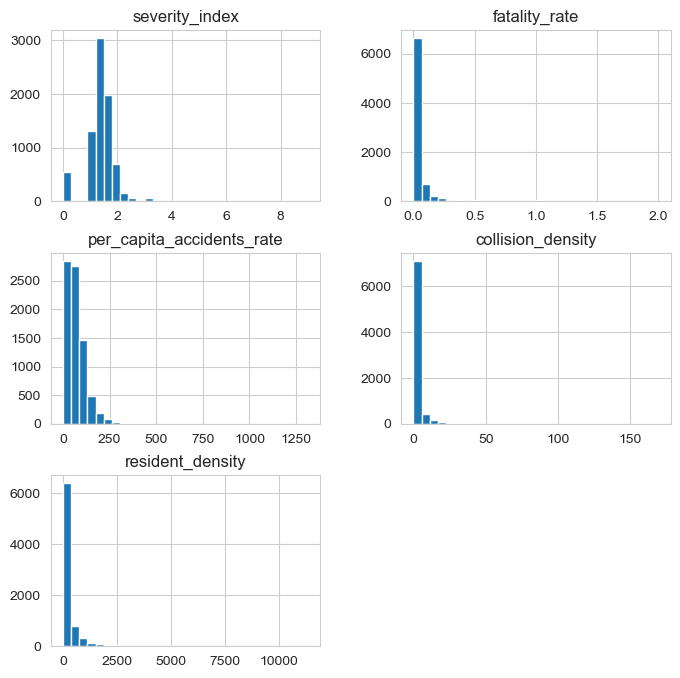

In [23]:
df_2021_24[metrics].hist(figsize=(8, 8), bins=30)

We can clearly see the different distributions of the metrics, but if we want to create a score that incorporates all the information, we must first identify the independent metrics. Otherwise, it's like counting the same information twice. The first and most obvious is the fatality rate, which is useful for seeing how many deaths occur in a city due to accidents, but it is not useful for the general score since it is a subset of the severity index. Collision density and resident density are both size measures and are correlated with the per capita accident rate. The resident metrics are useful for seeing if there was a change in population over the years.  
So instead of summing all 5 separatly we can create two group that explain two factor:
- Frequency: per_capita_accidents_rate, collision_density, resident_density combined
- Severity: severity_index and fatality_rate (with more weight to severity_index)
Then, we can add the two groups together to calculate the final score.


In [24]:
frequency_features = ['per_capita_accidents_rate', 'collision_density', 'resident_density']
severity_features  = ['severity_index', 'fatality_rate']

From the graph we can see that the distributions for `severity_index` and `per_capita_accidents_rate` are "similar" to a Gaussian, even though the latter has a long tail up to 200, while the other 3 do not. Therefore, it is better to transform and scale the five different distributions.
First we apply `np.log1p()` to the skewed ones so that they become more closer to a symmetric-normal distribution and then we scale with `RobustScaler`. But why use `RobustScaler` instead of another scaler?  
Since our data does not follow a properly normal distribution, a `StandardScaler` is not ideal because outliers deflect the standard deviation. The same logic applies to a `MinMax` scaler. Here, outliers set the maximum boundaries to [-1, 1], compressing the other values into a very small range. `RobustScaler`, on the other hand, scales the data using only the central 50%, ignoring the outliers completely.

$$
x = \dfrac{x - Q_2(x)}{Q_3(x) - Q_1(x)}
$$

- $Q_2(x)$ is the median
- $Q_3(x) - Q_1(x)$ is the IQR (Interquartile Range) which is the distance between the 75th percentile and the 25th percentile

In [25]:
from sklearn.preprocessing import RobustScaler, MinMaxScaler

pd.set_option('display.width', 1000) # cleaner print

def transform_and_scale(df, features, log_features):
    X = df[features].copy()
    for col in features:
        if col in log_features:
            X[col] = np.log1p(X[col].clip(lower=0))
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled, scaler

freq_scaled, freq_scaler = transform_and_scale(df_2021_24, frequency_features, log_features=['per_capita_accidents_rate', 'collision_density', 'resident_density'])
sev_scaled, sev_scaler = transform_and_scale(df_2021_24, severity_features, log_features=['fatality_rate'])

print(df_2021_24[frequency_features].corr())
print()
print(df_2021_24[severity_features].corr())

                           per_capita_accidents_rate  collision_density  resident_density
per_capita_accidents_rate                   1.000000           0.290310          0.084212
collision_density                           0.290310           1.000000          0.804488
resident_density                            0.084212           0.804488          1.000000

                severity_index  fatality_rate
severity_index        1.000000       0.158185
fatality_rate         0.158185       1.000000


Let's check correlation between metrics to actually see how they work togheter:
- collision_density <-> resident_density: are strongly correlated (0.80) and it makes sense: both are divide by area and dense population areas mechanically have more traffic and thus more raw accidents per km². This is largely the same signal twice so for this score is better to not consider resident density.
- per_capita_accidents_rate <-> collision_density are weak (0.29).

we can group by calculating the mean since 0.29 correlation isn't so high it invalidates averaging.

- severity_index and fatality_rate strangely are only weakly correlated, meaning they're capturing genuinely different aspects of severity (proportion of accidents that are harmful at all vs. proportion that are fatal specifically), not redundant measurements of the same thing. So mean of the two scaled features is the right call. This could be tranlated as a city can have "high severity" by having a high injury rate or a high fatality rate.

array([[<Axes: title={'center': 'frequency_subscore'}>,
        <Axes: title={'center': 'severity_subscore'}>]], dtype=object)

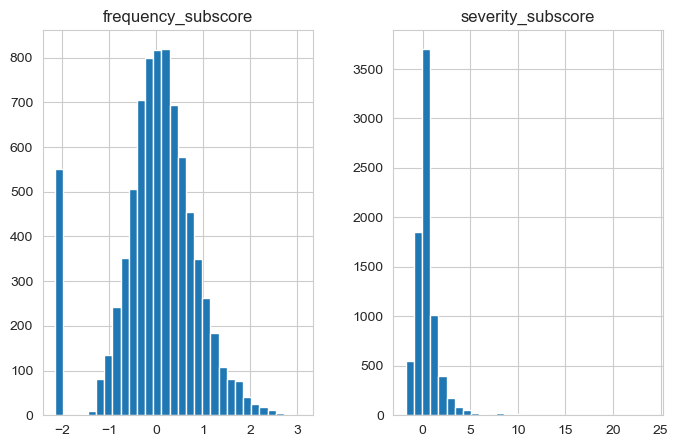

In [26]:
df_2021_24['frequency_subscore'] = freq_scaled[:,:2].mean(axis=1)  # removing resident_density
df_2021_24['severity_subscore']  = sev_scaled.mean(axis=1) 

df_2021_24[['frequency_subscore', 'severity_subscore']].hist(figsize=(8, 5), bins=30)

We can sum the two subscores with three different weights to see how they actually change the score. We can have equal weighting of 50-50, focus more on the frequency aspect, or focus more on the severity aspect. Since we don't know which is the better, we calculate all of them

In [27]:
# normalize before the final weighted sum

df_2021_24[['frequency_subscore', 'severity_subscore']] = MinMaxScaler().fit_transform(df_2021_24[['frequency_subscore', 'severity_subscore']])

weight_scenarios = {
    'equal':            {'frequency_subscore': 0.5, 'severity_subscore': 0.5},
    'frequency_heavy':  {'frequency_subscore': 0.7, 'severity_subscore': 0.3},
    'severity_heavy':   {'frequency_subscore': 0.3, 'severity_subscore': 0.7},
}

for name, w in weight_scenarios.items():
    df_2021_24[f'risk_score_{name}'] = (df_2021_24['frequency_subscore'] * w['frequency_subscore'] + df_2021_24['severity_subscore'] * w['severity_subscore'])

# how much does the top 20 list move across weighting scenarios?
top20_sets = {
    name: set(df_2021_24.nlargest(20, f'risk_score_{name}')['city_id'])
    for name in weight_scenarios
}

overlap_equal_freq = len(top20_sets['equal'] & top20_sets['frequency_heavy'])
overlap_equal_sev  = len(top20_sets['equal'] & top20_sets['severity_heavy'])
print(f"Top 20 overlap, equal vs frequency-heavy: {overlap_equal_freq}/20")
print(f"Top 20 overlap, equal vs severity-heavy:  {overlap_equal_sev}/20")


Top 20 overlap, equal vs frequency-heavy: 19/20
Top 20 overlap, equal vs severity-heavy:  1/20


In [28]:
stable_top = top20_sets['equal'] & top20_sets['frequency_heavy'] & top20_sets['severity_heavy']
print(f"Cities in all 3 top-20 lists: {len(stable_top)}")

Cities in all 3 top-20 lists: 0


This result is important because it tells us that no cities appear in all three scenarios. This could indicate that cities with the highest severity are not necessarily those with the highest frequency. 

In [29]:
# FINAL RANKING: take the equal weight scenario

df_2021_24[['city', 'province', 'region', 'risk_score_equal', 'degurba']].sort_values(by='risk_score_equal', ascending=False).head(20)

,city,province,region,risk_score_equal,degurba
2454,Verretto,PV,Lombardia,0.664064,3
1778,Milano,MI,Lombardia,0.532295,1
1863,Bergamo,BG,Lombardia,0.511637,1
4234,Firenze,FI,Toscana,0.507212,1
4180,Forte dei Marmi,LU,Toscana,0.502892,2
1749,Cormano,MI,Lombardia,0.490539,1
7434,Pescate,LC,Lombardia,0.489440,2
1744,Cinisello Balsamo,MI,Lombardia,0.489340,1
1267,Genova,GE,Liguria,0.487977,1
267,Torino,TO,Piemonte,0.482839,1


In [30]:
# FINAL RANKING: take the frequency weight scenario

df_2021_24[['city', 'province', 'region', 'risk_score_frequency_heavy', 'degurba']].sort_values(by='risk_score_frequency_heavy', ascending=False).head(20)

,city,province,region,risk_score_frequency_heavy,degurba
1778,Milano,MI,Lombardia,0.719377,1
1863,Bergamo,BG,Lombardia,0.690662,1
4234,Firenze,FI,Toscana,0.685730,1
4180,Forte dei Marmi,LU,Toscana,0.678188,2
1267,Genova,GE,Liguria,0.658902,1
1749,Cormano,MI,Lombardia,0.658456,1
1744,Cinisello Balsamo,MI,Lombardia,0.657853,1
7434,Pescate,LC,Lombardia,0.653888,2
7522,Riccione,RN,Emilia-Romagna,0.646823,2
267,Torino,TO,Piemonte,0.646281,1


In [31]:
# FINAL RANKING: take the severity weight scenario

df_2021_24[['city', 'province', 'region', 'risk_score_severity_heavy', 'degurba']].sort_values(by='risk_score_severity_heavy', ascending=False).head(20)

,city,province,region,risk_score_severity_heavy,degurba
2454,Verretto,PV,Lombardia,0.798438,3
5641,Ari,CH,Abruzzo,0.522827,3
5718,San Giovanni Lipioni,CH,Abruzzo,0.467079,3
5774,Limosano,CB,Molise,0.457797,3
5579,Pietracamela,TE,Abruzzo,0.454124,3
332,Cervatto,VC,Piemonte,0.425357,3
7158,Bagnoli del Trigno,IS,Molise,0.424965,3
939,Momperone,AL,Piemonte,0.422842,3
7366,Campiglia Cervo,BI,Piemonte,0.421259,3
6639,Alcara li Fusi,ME,Sicilia,0.418145,3


In [32]:
both_top = top20_sets['equal'] & top20_sets['frequency_heavy']
print(f"Cities in both equal and frequency-heavy top-20 lists:")
df_2021_24.loc[df_2021_24['city_id'].isin(both_top), ['city', 'province', 'region', 'mean_residents', 'mean_area_km2', 'degurba']]

Cities in both equal and frequency-heavy top-20 lists:


,city,province,region,mean_residents,mean_area_km2,degurba
267,Torino,TO,Piemonte,850135.25,130.040725,1
1176,Albissola Marina,SV,Liguria,5192.75,3.245700,2
1257,Chiavari,GE,Liguria,27360.75,12.280200,2
1267,Genova,GE,Liguria,562224.00,240.654200,1
1410,Gallarate,VA,Lombardia,52832.25,20.984800,1
1744,Cinisello Balsamo,MI,Lombardia,74637.00,12.724000,1
1749,Cormano,MI,Lombardia,20519.50,4.473300,1
1767,Legnano,MI,Lombardia,60287.25,17.697200,1
1778,Milano,MI,Lombardia,1361386.75,181.845000,1
1818,Sesto San Giovanni,MI,Lombardia,78968.00,11.698900,1


In [33]:
both_top2 = top20_sets['equal'] & top20_sets['severity_heavy']
print(f"Cities in both equal and severity-heavy top-20 lists:")
df_2021_24.loc[df_2021_24['city_id'].isin(both_top2), ['city', 'province', 'region', 'mean_residents', 'mean_area_km2', 'degurba']]

Cities in both equal and severity-heavy top-20 lists:


,city,province,region,mean_residents,mean_area_km2,degurba
2454,Verretto,PV,Lombardia,369.0,2.7086,3


It is interesting to note that, in terms of both equal and frequency weight scenarios, Lombardia is the region with the highest number of cities in the top 20, making it possibly the best region in which to invest in road safety. However, it is notable that Mottola, a small town in Puglia, ranks first for both equal and severity-heavy weight. Additionally, in the severity-heavy scenario, the majority of cities are in southern regions.   
One initial insight we can extract is that northern regions, especially Lombardy, have a high number of accidents, but with more simple collisions then serious accidents. Meanwhile, southern regions are the ones with the greatest number of serious accidents. This makes sense since northern region cities are densely populated and have heavy traffic, thanks to the large number of industries. Meanwhile, in the south, unfortunately, accidents are more likely to end tragically due to less maintained roads.  

Another insight we can get from the DEGURBA is that small- to medium-sized cities (grade 2) are generally more likely to have fatal accidents, while large cities (grade 1) are more likely to have non-fatal collisions. This could be explained by the fact that the mean velocity is typically quite low in huge urban areas because of traffic. In small cities, it is much easier to travel at higher speeds.

In [34]:
# -- saving usefull data --

# unfiltered df with metrics

# 1) Harmful Accidents (M + F)
df_pivot['harmful_accidents'] = df_pivot['fatalities'] + df_pivot['injuries']

# 2) Severity Index (where condition to taking into account possible division by zero)
df_pivot['severity_index'] = np.where(df_pivot['collisions'] > 0, df_pivot['harmful_accidents'] / df_pivot['collisions'], 0)

# 3) Fatality Rate
df_pivot['fatality_rate'] = np.where(df_pivot['collisions'] > 0, df_pivot['fatalities'] / df_pivot['collisions'], 0)

# 4) Per-Capita Accidents Rate
df_pivot['per_capita_accidents_rate'] = (df_pivot['collisions'] / df_pivot['residents']) * 1e4

# 5) Collision Density
df_pivot['collision_density'] = df_pivot['collisions'] / df_pivot['area (km2)']

# 6) Resident Density
df_pivot['resident_density'] = df_pivot['residents'] / df_pivot['area (km2)']

if not os.path.exists('data/istat_situa_traffic_accidents_2001_2024_metrics.csv'):
    df_pivot.to_csv('data/istat_situa_traffic_accidents_2001_2024_metrics.csv', index=False)

In [35]:
# 2024 data
if not os.path.exists('data/istat_situa_traffic_accidents_2021_2024_metrics.csv'):
    df_2021_24.to_csv('data/istat_situa_traffic_accidents_2021_2024_metrics.csv', index=False)

## HYPOTHESIS TEST

### 1. Is Lombardia actually the region with the highest risk score?
Based on prior results, we assumed that Lombardy was the region with the highest number of cities at high risk score and that it was the best region in which to invest. But is this true? To test this, we can perform a permutation test to determine whether our hypothesis is correct.  
The logic behinde is quite simple for this permutation test: 
1. We compute the observed difference: mean(risk score | Lombardia) − mean(risk score | rest of Italy)
2. We shuffle the region labels many times, recomputing that difference each time under the "no real relationship" null
3. We calculate our p-value

In addition to the p-value, we calculate also the effect size with Cohen's d (https://www.statology.org/interpret-cohens-d/), which tell us how large this difference actually is.

In [36]:
from scipy.stats import permutation_test

def mean_diff(x, y):
    return np.mean(x) - np.mean(y)

def cohens_d(g1, g2):
    pooled_std = np.sqrt((np.var(g1, ddof=1) + np.var(g2, ddof=1)) / 2)
    return (np.mean(g1) - np.mean(g2)) / pooled_std

# check overall investment priority
test_0 = {
    'Lombardia_high_overall_risk_equal': (
        df_2021_24.loc[df_2021_24['region'] == 'Lombardia', 'risk_score_equal'].values,
        df_2021_24.loc[df_2021_24['region'] != 'Lombardia', 'risk_score_equal'].values
    ),
    'Lombardia_high_overall_risk_frequency': (
            df_2021_24.loc[df_2021_24['region'] == 'Lombardia', 'risk_score_frequency_heavy'].values,
            df_2021_24.loc[df_2021_24['region'] != 'Lombardia', 'risk_score_frequency_heavy'].values
        ),
}

rows = []
for name, (g1, g2) in test_0.items():
    res = permutation_test((g1, g2), statistic=mean_diff, n_resamples=10000,
                            alternative='greater', random_state=42)
    rows.append({
        'test': name,
        'n_group': len(g1),
        'n_rest': len(g2),
        'group_mean': np.mean(g1),
        'rest_mean': np.mean(g2),
        'observed_diff': res.statistic,
        'p_value': res.pvalue,
        'cohens_d': cohens_d(g1, g2),
    })

summary = pd.DataFrame(rows)
summary['significant'] = summary['p_value'] < 0.05
print(summary.to_string(index=False))

                                 test  n_group  n_rest  group_mean  rest_mean  observed_diff  p_value  cohens_d  significant
    Lombardia_high_overall_risk_equal     1508    6402    0.272425   0.244383       0.028043   0.0001  0.307425         True
Lombardia_high_overall_risk_frequency     1508    6402    0.348978   0.307443       0.041535   0.0001  0.346930         True


We tested the hypothesis for equal-weight risk score (risk_score_equal) and frequency-dependent risk score (risk_score_frequency_heavy). In the first case, the null hypothesis is not rejected, but in the second case, it is. 
It is incorrect to say that Lombardia is the best region in which to invest based solely on the general risk score, since it is not statistically significant. However, if we are more interested in frequency than severity, we see that Lombardia is one of the best options for investment.

### 2. Other Hypothesis
Before drawing our final conclusions from the results of the top 20 cities by risk score, we will extract some raw hypotheses:
- Lomardia has the majority of cities for frequency of accidents
- DEGURBA class 1 cities are those with the highest frequency of accidents
- Southern regions are those with the highest severity
- and DEGURBA class 2 cities are the ones with the highest severity  

To see if this trend is actually true, we will run the permutation test again with some differences. We will use the two different subscores instead of the risk score: the frequency subscore for the first two points and the severity subscore for the last two points.
In short, our full hypothesis is confirmed if all four points are satisfied (their p-values must be lower than 0.05), but the general p-values must be calculated differently since it is a multiple comparison.  
To do that we must taking into account the multiple comparison problems, and so apply the Bonferroni correction to the p-values (https://en.wikipedia.org/wiki/Bonferroni_correction). In shorts words is basically divide the p-value by the total number of the null hypothesis (in our case 4) which give as a p-values of 0.0125. To have a much more cleaner result we can rely on statismodel.

In [37]:
from statsmodels.stats.multitest import multipletests

# create a mask for southern regions
df_2021_24['is_south'] = df_2021_24['region'].isin(south+islands)

# check overall investment priority
tests = {
    'Lombardia_high_frequency': (
        df_2021_24.loc[df_2021_24['region'] == 'Lombardia', 'frequency_subscore'].values,
        df_2021_24.loc[df_2021_24['region'] != 'Lombardia', 'frequency_subscore'].values
    ),
    'Degurba1_high_frequency': (
        df_2021_24.loc[df_2021_24['degurba'] == 1, 'frequency_subscore'].values,
        df_2021_24.loc[df_2021_24['degurba'] != 1, 'frequency_subscore'].values
    ),
    'South_high_severity': (
        df_2021_24.loc[df_2021_24['is_south'], 'severity_subscore'].values,
        df_2021_24.loc[~df_2021_24['is_south'], 'severity_subscore'].values
    ),
    'Degurba2_high_severity': (
        df_2021_24.loc[df_2021_24['degurba'] == 2, 'severity_subscore'].values,
        df_2021_24.loc[df_2021_24['degurba'] != 2, 'severity_subscore'].values
    ),
}

rows = []
for name, (g1, g2) in tests.items():
    res = permutation_test((g1, g2), statistic=mean_diff, n_resamples=10000,
                            alternative='greater', random_state=42)
    rows.append({
        'test': name,
        'n_group': len(g1),
        'n_rest': len(g2),
        'group_mean': np.mean(g1),
        'rest_mean': np.mean(g2),
        'observed_diff': res.statistic,
        'p_value': res.pvalue,
        'cohens_d': cohens_d(g1, g2),
    })

summary = pd.DataFrame(rows)
summary['p_adj'] = multipletests(summary['p_value'], method='bonferroni')[1]
summary['significant'] = summary['p_value'] < 0.05
print(summary.to_string(index=False))

                    test  n_group  n_rest  group_mean  rest_mean  observed_diff  p_value  cohens_d  p_adj  significant
Lombardia_high_frequency     1508    6402    0.463808   0.402033       0.061774 0.000100  0.373936 0.0004         True
 Degurba1_high_frequency      298    7612    0.671011   0.403741       0.267270 0.000100  1.893433 0.0004         True
     South_high_severity     2551    5359    0.093072   0.082113       0.010959 0.000100  0.202658 0.0004         True
  Degurba2_high_severity     2462    5448    0.084397   0.086212      -0.001815 0.925907 -0.039538 1.0000        False


We can see that the null hypothesis has been completely rejected in all the tests, which is positive and confirms our hypothesis regarding the trend. However, looking at the effect size for each one, we can see in particular that cities with DEGURBA 1 are the ones with the highest frequency of accidents; therefore, the trend is not regional but urban.  
On the other hand, the hypothesis that southern regions have the highest number of fatal accidents (severity) is true and strong (cohens_d = 0.84), while the hypothesis that small-to-medium-sized cities have the highest number of fatal accidents is also true but has a small effect size.

In [38]:
test = {
    'Lombardia_high_frequency': (
        df_2021_24.loc[(df_2021_24['region'] == 'Lombardia')&(df_2021_24['degurba'] == 1), 'frequency_subscore'].values,
        df_2021_24.loc[(df_2021_24['region'] != 'Lombardia')&(df_2021_24['degurba'] == 1), 'frequency_subscore'].values
    ),
}

rows = []
for name, (g1, g2) in test.items():
    res = permutation_test((g1, g2), statistic=mean_diff, n_resamples=10000,
                            alternative='greater', random_state=42)
    rows.append({
        'test': name,
        'n_group': len(g1),
        'n_rest': len(g2),
        'group_mean': np.mean(g1),
        'rest_mean': np.mean(g2),
        'observed_diff': res.statistic,
        'p_value': res.pvalue,
        'cohens_d': cohens_d(g1, g2),
    })

summary = pd.DataFrame(rows)
summary['significant'] = summary['p_value'] < 0.05
print(summary.to_string(index=False))

                    test  n_group  n_rest  group_mean  rest_mean  observed_diff  p_value  cohens_d  significant
Lombardia_high_frequency      118     180    0.701947   0.650731       0.051216   0.0003  0.427005         True


This test also shows that Lombardy is the region with the highest number of DEGURBA Class 1 cities. The majority of accidents occur in these cities compared to all other Italian cities in the same class. We could say that the majority of accidents occur in Lombardy's cities, but they are simple collisions and not serious accidents.

## Conclusion

So, what's the final answer? It depends on where we want to invest!
We can provide an answer for each category of investment.   
1. **Frequency focused:** If our goal is to determine where to invest based more on frequency than seriousness, then we are looking for big cities (DEGURBA = 1), particularly in Lombardy, where there are more collisions than serious accidents. Our top 20 is:

In [39]:
top_20_frequency = df_2021_24[['city', 'province', 'region', 'mean_residents', 'total_collisions', 'degurba', 'risk_score_frequency_heavy']].sort_values(by='risk_score_frequency_heavy', ascending=False).head(20)

if not os.path.exists('data/results/top_20_frequency.csv'):
    top_20_frequency.to_csv('data/results/top_20_frequency.csv', index=False)

top_20_frequency

,city,province,region,mean_residents,total_collisions,degurba,risk_score_frequency_heavy
1778,Milano,MI,Lombardia,1361386.75,30803.0,1,0.719377
1863,Bergamo,BG,Lombardia,119957.75,3562.0,1,0.690662
4234,Firenze,FI,Toscana,362169.75,9526.0,1,0.685730
4180,Forte dei Marmi,LU,Toscana,6816.25,383.0,2,0.678188
1267,Genova,GE,Liguria,562224.00,15035.0,1,0.658902
1749,Cormano,MI,Lombardia,20519.50,374.0,1,0.658456
1744,Cinisello Balsamo,MI,Lombardia,74637.00,1196.0,1,0.657853
7434,Pescate,LC,Lombardia,2152.75,82.0,2,0.653888
7522,Riccione,RN,Emilia-Romagna,34480.50,918.0,2,0.646823
267,Torino,TO,Piemonte,850135.25,11614.0,1,0.646281


2. **Severity focused:** If our goal is to determine where to invest based more on seriousness than frequency, then we are looking for medium cities (DEGURBA = 2), expecially in souther regions, where there are more serious accidents. Our top 20 is:

In [40]:
top_20_severity = df_2021_24[['city', 'province', 'region', 'mean_residents', 'total_collisions', 'degurba', 'risk_score_severity_heavy']].sort_values(by='risk_score_severity_heavy', ascending=False).head(20)

if not os.path.exists('data/results/top_20_severity.csv'):
    top_20_severity.to_csv('data/results/top_20_severity.csv', index=False)

top_20_severity

,city,province,region,mean_residents,total_collisions,degurba,risk_score_severity_heavy
2454,Verretto,PV,Lombardia,369.000000,1.0,3,0.798438
5641,Ari,CH,Abruzzo,1067.250000,1.0,3,0.522827
5718,San Giovanni Lipioni,CH,Abruzzo,137.000000,1.0,3,0.467079
5774,Limosano,CB,Molise,688.000000,1.0,3,0.457797
5579,Pietracamela,TE,Abruzzo,215.666667,2.0,3,0.454124
332,Cervatto,VC,Piemonte,48.000000,1.0,3,0.425357
7158,Bagnoli del Trigno,IS,Molise,635.333333,1.0,3,0.424965
939,Momperone,AL,Piemonte,198.333333,1.0,3,0.422842
7366,Campiglia Cervo,BI,Piemonte,508.000000,5.0,3,0.421259
6639,Alcara li Fusi,ME,Sicilia,1681.250000,2.0,3,0.418145


3. **Equally focused:** If our goal is to determine where to invest based on seriousness and frequency, there is no specific trend. However, based on data from 2021 to 2024, our top 20 is:

In [41]:
top_20_equal = df_2021_24[['city', 'province', 'region', 'mean_residents', 'total_collisions', 'degurba', 'risk_score_equal']].sort_values(by='risk_score_equal', ascending=False).head(20)

if not os.path.exists('data/results/top_20_equal.csv'):
    top_20_equal.to_csv('data/results/top_20_equal.csv', index=False)

top_20_equal

,city,province,region,mean_residents,total_collisions,degurba,risk_score_equal
2454,Verretto,PV,Lombardia,369.00,1.0,3,0.664064
1778,Milano,MI,Lombardia,1361386.75,30803.0,1,0.532295
1863,Bergamo,BG,Lombardia,119957.75,3562.0,1,0.511637
4234,Firenze,FI,Toscana,362169.75,9526.0,1,0.507212
4180,Forte dei Marmi,LU,Toscana,6816.25,383.0,2,0.502892
1749,Cormano,MI,Lombardia,20519.50,374.0,1,0.490539
7434,Pescate,LC,Lombardia,2152.75,82.0,2,0.489440
1744,Cinisello Balsamo,MI,Lombardia,74637.00,1196.0,1,0.489340
1267,Genova,GE,Liguria,562224.00,15035.0,1,0.487977
267,Torino,TO,Piemonte,850135.25,11614.0,1,0.482839
